# Maximum usable PEM discharge power

Goal: estimate the maximum PEM power that is usable by the EMS.

I use the polarization/load sweep because it directly shows voltage, current, and power at different
loads. The maximum usable power is not the largest absolute power in the sweep. It is the largest
power while the PEM voltage is still above the voltage cutoff.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This makes the notebook work both from the repo root and from its own folder.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 1. Load and inspect the polarization sweep


In [3]:
sweep_file = PROJECT_ROOT / "data/PEM_test/current_sweep/PEM_polarization_characteristics.csv"
sweep_raw = pd.read_csv(sweep_file)

print("Rows:", len(sweep_raw))
display(sweep_raw.head())


Rows: 2892


,timestamp,scenario,mode,K1,K2,K3,K4,K5,K6,K7,ina1_ok,ina1_bus_V,ina1_current_mA,ina1_power_mW,ina1_shunt_mV,ina2_ok,ina2_bus_V,ina2_current_mA,ina2_power_mW,ina2_shunt_mV,ina3_ok,ina3_bus_V,ina3_current_mA,ina3_power_mW,ina3_shunt_mV,ina4_ok,ina4_bus_V,ina4_current_mA,ina4_power_mW,ina4_shunt_mV
0,2026-05-05T09:40:27,1,Scenario 1: Grid -> Load,1,0,1,1,1,1,1,1,3.4462,-0.025,0.0,-0.0025,1,0.0,0.000,0.0,0.0000,1,4.4437,-0.125,1.25,-0.0125,1,1.2725,-0.05,0.0,-0.005
1,2026-05-05T09:40:28,1,Scenario 1: Grid -> Load,1,0,1,1,1,1,1,1,3.4475,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,4.4437,-0.125,1.25,-0.0125,1,1.2725,-0.05,0.0,-0.005
2,2026-05-05T09:40:29,1,Scenario 1: Grid -> Load,1,0,1,1,1,1,1,1,3.4475,-0.025,0.0,-0.0025,1,0.0,0.000,0.0,0.0000,1,4.4412,-0.125,1.25,-0.0125,1,1.2725,-0.05,0.0,-0.005
3,2026-05-05T09:40:30,1,Scenario 1: Grid -> Load,1,0,1,1,1,1,1,1,3.4475,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,0.0812,-0.125,0.00,-0.0125,1,1.2713,-0.05,0.0,-0.005
4,2026-05-05T09:40:31,1,Scenario 1: Grid -> Load,1,0,1,1,1,1,1,1,3.4475,-0.025,0.0,-0.0025,1,0.0,0.000,0.0,0.0000,1,4.4363,-0.125,1.25,-0.0125,1,1.2713,-0.05,0.0,-0.005


## 2. Correct voltage and current and select discharge data


Implementing the correction factors based on ina Tests 

In [4]:
sweep = sweep_raw.copy()
sweep["timestamp"] = pd.to_datetime(sweep["timestamp"])
sweep["time_s"] = (sweep["timestamp"] - sweep["timestamp"].iloc[0]).dt.total_seconds()
sweep["pem_voltage_V"] = sweep["ina4_bus_V"] - 0.064
sweep["pem_current_A"] = 0.843 * (sweep["ina4_current_mA"] / 1000) + 0.001
sweep["load_current_A"] = (-sweep["pem_current_A"]).clip(lower=0)
sweep["pem_power_W"] = sweep["pem_voltage_V"] * sweep["load_current_A"]

discharge = sweep[(sweep["scenario"] == 6) & (sweep["load_current_A"] > 0)].copy()
discharge["discharge_time_s"] = discharge["time_s"] - discharge["time_s"].iloc[0]

display(discharge[["discharge_time_s", "pem_voltage_V", "load_current_A", "pem_power_W"]].head())


,discharge_time_s,pem_voltage_V,load_current_A,pem_power_W
1018,0.0,1.2172,0.000033,0.000040
1019,1.0,1.2147,0.000538,0.000654
1020,2.0,1.2110,0.001445,0.001750
1021,3.0,1.2097,0.001403,0.001697
1022,4.0,1.2060,0.001403,0.001691


## 3. Average the sweep into load steps


In [5]:
STEP_LENGTH_S = 10
discharge["step_index"] = (discharge["discharge_time_s"] // STEP_LENGTH_S).astype(int)

step_summary = (
    discharge.groupby("step_index")
    .agg(
        current_A=("load_current_A", "mean"),
        voltage_V=("pem_voltage_V", "mean"),
        power_W=("pem_power_W", "mean"),
    )
    .reset_index()
)
step_summary["power_mW"] = step_summary["power_W"] * 1000

display(step_summary.head(15))


,step_index,current_A,voltage_V,power_W,power_mW
0,0,0.001164,1.206256,0.001401,1.401220
1,1,0.001415,1.179630,0.001669,1.669374
2,2,0.004362,1.141567,0.004927,4.926994
3,3,0.007664,1.043640,0.007998,7.997593
4,4,0.007765,0.939322,0.007293,7.293197
5,5,0.010332,0.827000,0.008472,8.472378
6,6,0.012036,0.708233,0.008525,8.525403
7,7,0.011923,0.630370,0.007517,7.516716
8,8,0.015017,0.593911,0.008905,8.905138
9,9,0.017483,0.597850,0.010452,10.452257


## 4. Apply the voltage cutoff


In [6]:
PEM_MIN_USABLE_VOLTAGE = 0.54975

# The sweep later turns back down after collapse. I only keep the increasing-current branch.
step_summary["is_increasing_current"] = step_summary["current_A"].diff().fillna(0) >= 0
step_summary["is_above_cutoff"] = step_summary["voltage_V"] >= PEM_MIN_USABLE_VOLTAGE
step_summary["is_usable"] = step_summary["is_increasing_current"] & step_summary["is_above_cutoff"] & (step_summary["power_W"] > 0)

usable_steps = step_summary[step_summary["is_usable"]].copy()
best_usable = usable_steps.loc[usable_steps["power_W"].idxmax()]
absolute_best = step_summary.loc[step_summary["power_W"].idxmax()]

print("Best usable step:")
display(best_usable.to_frame().T)

print("Absolute best power step, shown for comparison:")
display(absolute_best.to_frame().T)


Best usable step:


,step_index,current_A,voltage_V,power_W,power_mW,is_increasing_current,is_above_cutoff,is_usable
35,35,0.06167,0.550144,0.033921,33.921472,True,True,True


Absolute best power step, shown for comparison:


,step_index,current_A,voltage_V,power_W,power_mW,is_increasing_current,is_above_cutoff,is_usable
54,54,0.0921,0.4545,0.041859,41.859471,True,False,False


## 5. Plot why the EMS limit is lower than the absolute maximum


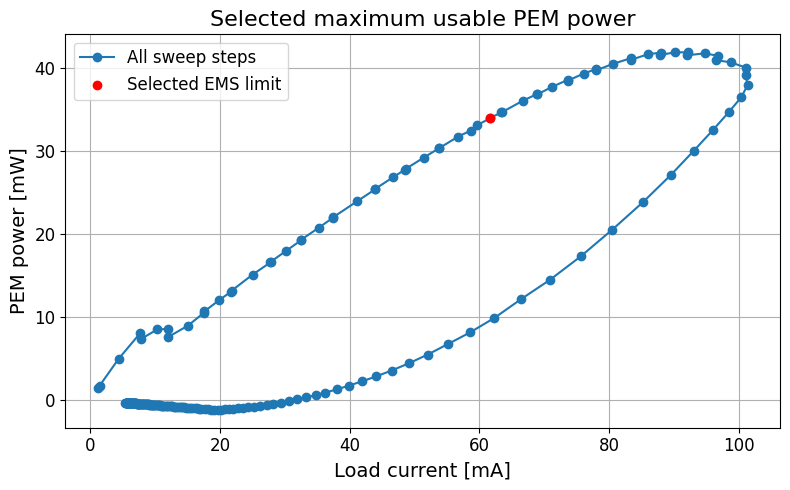

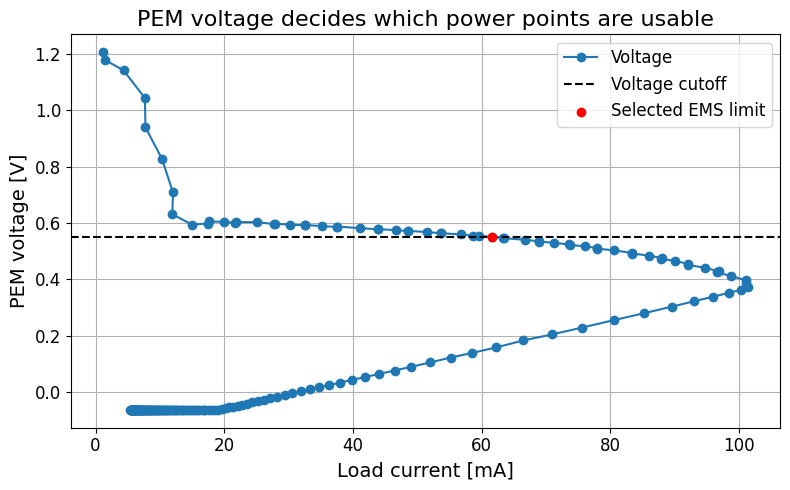

In [ ]:
label_size = 14
title_size = 16
tick_size = 12
legend_size = 12

# Convert units for plotting
step_summary["current_mA"] = step_summary["current_A"] * 1000
step_summary["power_mW"] = step_summary["power_W"] * 1000

best_current_mA = best_usable["current_A"] * 1000
best_power_mW = best_usable["power_W"] * 1000
best_voltage_V = best_usable["voltage_V"]

plt.figure(figsize=(8, 5))
plt.plot(
    step_summary["current_mA"],
    step_summary["power_mW"],
    marker="o",
    label="All sweep steps"
)
plt.scatter(
    best_current_mA,
    best_power_mW,
    color="red",
    zorder=5,
    label="Cutoff point"
)
plt.xlabel("Load current [mA]", fontsize=label_size)
plt.ylabel("PEM power [mW]", fontsize=label_size)
plt.title("Selected maximum usable PEM power", fontsize=title_size)
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
plt.grid(True)
plt.legend(fontsize=legend_size)
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(
    step_summary["current_mA"],
    step_summary["voltage_V"],
    marker="o",
    label="Voltage"
)
plt.axhline(
    PEM_MIN_USABLE_VOLTAGE,
    color="black",
    linestyle="--",
    label="Voltage cutoff"
)
plt.scatter(
    best_current_mA,
    best_voltage_V,
    color="red",
    zorder=5,
    label="Cutoff point"
)
plt.xlabel("Load current [mA]", fontsize=label_size)
plt.ylabel("PEM voltage [V]", fontsize=label_size)
plt.title("PEM voltage decides which power points are usable", fontsize=title_size)
plt.xticks(fontsize=tick_size)
plt.yticks(fontsize=tick_size)
plt.grid(True)
plt.legend(fontsize=legend_size)
plt.tight_layout()
plt.show()

## 6. Values to use in the app


In [8]:
PEM_MAX_DISCHARGE_CURRENT_A = best_usable["current_A"]
PEM_MAX_DISCHARGE_POWER_W = best_usable["power_W"]

pem_power_parameters = pd.DataFrame(
    {
        "parameter": [
            "PEM_MIN_USABLE_VOLTAGE",
            "PEM_MAX_DISCHARGE_CURRENT_A",
            "PEM_MAX_DISCHARGE_POWER_W",
        ],
        "value": [
            PEM_MIN_USABLE_VOLTAGE,
            PEM_MAX_DISCHARGE_CURRENT_A,
            PEM_MAX_DISCHARGE_POWER_W,
        ],
        "unit": ["V", "A", "W"],
        "meaning": [
            "Fuel cell voltage cutoff",
            "Current at highest usable sweep point",
            "Highest power above cutoff on the increasing-current branch",
        ],
    }
)

display(pem_power_parameters)


,parameter,value,unit,meaning
0,PEM_MIN_USABLE_VOLTAGE,0.549750,V,Fuel cell voltage cutoff
1,PEM_MAX_DISCHARGE_CURRENT_A,0.061670,A,Current at highest usable sweep point
2,PEM_MAX_DISCHARGE_POWER_W,0.033921,W,Highest power above cutoff on the increasing-c...
